# Predictive model comparison

Notebook 04 established interpretable frequency and severity GLM benchmarks and revealed important limitations, especially unstable severity means and unsupported BonusMalus spline behavior. This notebook compares a small set of candidates on **out-of-fold predictive performance and stability**. The target quantities remain expected claim frequency per exposure-year and expected claim severity per claim.

Model selection used only the 80% development sample. The final 20% policy-level test sample was reserved until candidate selection and refitting were complete, then evaluated once in Notebook 07.

## 1. Development framework

This notebook loads only the development policy extract and saved Notebook 05 out-of-fold (OOF) files. The extract contains exactly the policy IDs in the existing frequency OOF file, with their existing fold assignments. Claim rows and observed amounts come from the saved severity OOF file. The original split and five policy folds are preserved; no reserved test data are loaded. All metrics below use the original predictions. Fold refits in Section 10 only recover the fitted objects for response diagnostics and must reproduce those predictions.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_dir = Path("../data")
processed_dir = data_dir / "processed"
frequency_path = processed_dir / "05_frequency_oof.csv"
severity_path = processed_dir / "05_severity_oof.csv"
oof_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
              for p in [frequency_path, severity_path]}
frequency_oof = pd.read_csv(frequency_path, dtype={"IDpol": "string"})
severity_oof = pd.read_csv(severity_path, dtype={"IDpol": "string"})
development_policies = pd.read_csv(
    processed_dir / "05_development_policies.csv", dtype={"IDpol": "string"}
)
pd.testing.assert_frame_equal(
    development_policies[["IDpol", "cv_fold", "Exposure", "ClaimNb"]],
    frequency_oof[["IDpol", "cv_fold", "Exposure", "ClaimNb"]],
)
development_claims = severity_oof[["development_claim_row", "IDpol", "cv_fold", "ClaimAmount"]].merge(
    development_policies.drop(columns=["cv_fold", "ClaimNb", "Exposure"]),
    on="IDpol", how="left", validate="many_to_one",
)
assert development_claims["DrivAge"].notna().all()
assert development_claims.groupby("IDpol")["cv_fold"].nunique().eq(1).all()
assert development_claims.cv_fold.eq(development_claims.IDpol.map(
    development_policies.set_index("IDpol").cv_fold)).all()
assert severity_oof.development_claim_row.is_unique
assert set(frequency_oof.cv_fold) == set(severity_oof.cv_fold) == set(range(1, 6))
plot_dir = Path("../images/plots/05_predictive_model_comparison")
plot_dir.mkdir(parents=True, exist_ok=True)
table_dir = processed_dir / "05_diagnostics"
table_dir.mkdir(exist_ok=True)

def save_plot(fig, name):
    fig.tight_layout()
    fig.savefig(plot_dir / (name + ".png"), dpi=180, bbox_inches="tight")
    plt.show()

print(f"Development policies: {len(development_policies):,}")
print(f"Development claims: {len(development_claims):,}")
print("Existing policy IDs, fold assignments, exposures and claim counts verified.")

Development policies: 542,830
Development claims: 21,079
Existing policy IDs, fold assignments, exposures and claim counts verified.


## 2. Candidate and evaluation plan

The initial comparison uses five fixed candidates: exposure-adjusted Poisson and Negative Binomial GLMs, boosted claim frequency, a Gamma log-link GLM, and boosted positive severity. Their feature handling and fixed settings are specified below. None inherits Notebook 04's unrestricted BonusMalus spline. A lognormal regression benchmark is now added with the same conventional predictors. Normal-theory and smearing retransformation are two checks on that single log regression. Explicit body/tail modeling is reserved for Notebook 06.

All candidates use the **same policy folds** and produce one saved out-of-fold prediction per development policy or claim. Frequency comparisons report observed/predicted claim totals, mean Poisson deviance, and calibration by predicted-risk group. Severity comparisons report observed/predicted aggregate amount, MAE, RMSE, calibration by predicted-risk group, and sensitivity of aggregate results to the largest 1, 5, and 20 *observed* claims in each validation fold. RMSE is expected to be highly sensitive to catastrophes and will not stand alone as a selection rule. Fold-level results and predictor-response stability, especially for driver age and BonusMalus, are examined before selecting models.

This notebook ended with a development-stage conventional-model selection. Notebook 06 subsequently examined extreme severity using development data, and Notebook 07 completed full-development refitting and final test evaluation.

## 3. Initial candidate specifications

The three GLMs use the same compact predictors: log driver age, log BonusMalus, log(1 + vehicle age), vehicle power, fuel, log density, and region. Log transforms remain defined at the observed values and avoid the high-boundary spline extrapolation in Notebook 04. They are deliberately simple benchmarks, not claims about the final functional form. The Negative Binomial GLM's variance parameter `alpha` is estimated separately **inside each fitting fold** from the Poisson fit by a nonnegative moment estimate; both GLMs use exposure as an offset. The Gamma GLM targets arithmetic mean claim amount with a log link.

The boosted models use histogram gradient boosting (`scikit-learn`) with Poisson and Gamma losses. They use the raw numerical predictors and native categorical splits for fuel and region. For frequency, the target is claims per exposure-year and exposure is its sample weight, aligning the weighted Poisson objective with policy claim counts. Settings are fixed in advance: 150 iterations, learning rate 0.05, at most 15 leaves, at least 100 policy or 50 claim rows per leaf, L2 regularization 10, and no internal early-stopping split. These are first-pass baselines, not tuned models. Predictors `Area` and `VehBrand` remain excluded for comparability with the compact GLMs.

In [2]:
import statsmodels.api as sm
from scipy.special import xlogy
from sklearn.ensemble import HistGradientBoostingRegressor

glm_predictors = (
    "np.log(DrivAge) + np.log(BonusMalus) + np.log1p(VehAge)"
    " + VehPower + C(VehGas) + np.log(Density) + C(Region)"
)
tree_columns = ["DrivAge", "BonusMalus", "VehAge", "VehPower",
                "VehGas", "Density", "Region"]
category_levels = {
    column: sorted(development_policies[column].dropna().unique())
    for column in ["VehGas", "Region"]
}

def tree_features(frame):
    features = frame[tree_columns].copy()
    for column, levels in category_levels.items():
        features[column] = pd.Categorical(features[column], categories=levels)
    return features

frequency_candidates = ["Poisson GLM", "Negative Binomial GLM", "Boosted Poisson"]
severity_candidates = ["Gamma GLM", "Boosted Gamma"]

## 4. Saved frequency predictions

The original three sets of policy-count OOF predictions are loaded from disk. Annual frequency is obtained by dividing predicted counts by policy exposure. The original fitting recipes are reproduced only in Section 10 to retain fold-specific models.

In [3]:
assert frequency_oof[frequency_candidates].notna().all().all()
assert np.isfinite(frequency_oof[frequency_candidates]).all().all()
assert frequency_oof[frequency_candidates].gt(0).all().all()
display(frequency_oof.groupby("cv_fold").agg(policies=("IDpol", "size"), exposure=("Exposure", "sum")))

,policies,exposure
cv_fold,,
1,108566,57553.699364
2,108566,57431.080664
3,108566,57304.544758
4,108566,57478.834446
5,108566,57335.509428


## 5. Saved severity predictions

The original two sets of claim-level OOF predictions are retained exactly. Each claim is identified by its existing development row number; claims on the same policy share a fold.

In [4]:
assert severity_oof[severity_candidates].notna().all().all()
assert np.isfinite(severity_oof[severity_candidates]).all().all()
assert severity_oof[severity_candidates].gt(0).all().all()
display(severity_oof.groupby("cv_fold").agg(claims=("IDpol", "size"), observed_amount=("ClaimAmount", "sum")))

,claims,observed_amount
cv_fold,,
1,4184,11090200.65
2,4275,12424027.67
3,4165,8495496.07
4,4288,8599501.23
5,4167,7565921.59


### 5.1 Lognormal regression and original-dollar retransformation

Fit `log(ClaimAmount)` by ordinary least squares using exactly the Gamma GLM's predictors. This specifies the conditional log amount, $m(X)$, rather than `log E[Y|X]`. Under the normal log-error assumption, $\exp(m(X))$ is the conditional median. Every evaluation below instead uses an estimated **arithmetic mean on the original amount scale**.

For each fitting fold, normal-theory retransformation uses $\exp(\hat m(X)+\hat\sigma^2/2)$, with the normal maximum-likelihood variance estimate $\hat\sigma^2=\sum e_i^2/n$ from that fitting fold. A compact robustness check uses Duan's empirical factor $\hat S=n^{-1}\sum\exp(e_i)$ from the same fitting residuals. Both multiply the same fitted median curve; neither uses validation outcomes to estimate the correction. Log-scale R-squared is not a selection criterion.

The lognormal has a heavier right tail than a Gamma distribution, but that alone need not yield better expected-dollar predictions. Normal-theory correction assumes homoskedastic normal log errors. Global smearing relaxes log-error normality but still assumes that the conditional exponential residual mean is adequately represented by one factor; it does not solve arbitrary heteroskedasticity. It can itself be sensitive to rare large fitting claims. Correction factors and the largest fitting residual's share of the smearing sum are reported explicitly.

In [5]:
import joblib
import sklearn
import statsmodels

lognormal_names = ["Lognormal (normal)", "Lognormal (smearing)"]
lognormal_formula = "np.log(ClaimAmount) ~ " + glm_predictors
model_dir = Path("../models/05_cv")
lognormal_oof = severity_oof[["development_claim_row", "IDpol", "cv_fold", "ClaimAmount"]].copy()
lognormal_oof["predicted_log_amount"] = np.nan
for name in lognormal_names:
    lognormal_oof[name] = np.nan
correction_rows = []
versions = {"numpy": np.__version__, "pandas": pd.__version__,
            "sklearn": sklearn.__version__, "statsmodels": statsmodels.__version__}

for fold_id in range(1, 6):
    fitting = development_claims.loc[development_claims.cv_fold.ne(fold_id)]
    validation = development_claims.loc[development_claims.cv_fold.eq(fold_id)]
    assert set(fitting.IDpol).isdisjoint(set(validation.IDpol))
    model_path = model_dir / f"lognormal_fold_{fold_id}.joblib"
    if model_path.exists():
        artifact = joblib.load(model_path)
        assert artifact["oof_hashes"] == oof_hashes and artifact["versions"] == versions
        assert artifact["formula"] == lognormal_formula
        fitted = artifact["model"]
        correction = artifact["correction"]
    else:
        fitted = sm.OLS.from_formula(lognormal_formula, data=fitting).fit()
        residual = np.asarray(fitted.resid)
        sigma_squared = np.mean(residual ** 2)
        exponential_residual = np.exp(residual)
        correction = {
            "fold": fold_id, "fitting_claims": len(fitting),
            "sigma_squared_MLE": sigma_squared,
            "normal_factor": np.exp(sigma_squared / 2),
            "smearing_factor": exponential_residual.mean(),
            "largest_residual_share_of_smearing_sum": exponential_residual.max() / exponential_residual.sum(),
        }
        expected_log = np.asarray(fitted.predict(validation))
        fitted.remove_data()
        artifact = {"model": fitted, "fold": fold_id, "formula": lognormal_formula,
                    "correction": correction, "oof_hashes": oof_hashes, "versions": versions}
        joblib.dump(artifact, model_path, compress=3)
        fitted = joblib.load(model_path)["model"]
        np.testing.assert_allclose(fitted.predict(validation), expected_log, rtol=1e-12, atol=1e-12)
    log_prediction = np.asarray(fitted.predict(validation))
    lognormal_oof.loc[validation.index, "predicted_log_amount"] = log_prediction
    lognormal_oof.loc[validation.index, lognormal_names[0]] = np.exp(log_prediction) * correction["normal_factor"]
    lognormal_oof.loc[validation.index, lognormal_names[1]] = np.exp(log_prediction) * correction["smearing_factor"]
    correction_rows.append(correction)

assert np.isfinite(lognormal_oof[lognormal_names]).all().all()
assert lognormal_oof[lognormal_names].gt(0).all().all()
lognormal_oof.to_csv(processed_dir / "05_lognormal_severity_oof.csv", index=False)
for name in lognormal_names:
    severity_oof[name] = lognormal_oof[name]
severity_candidates = ["Gamma GLM", "Boosted Gamma"] + lognormal_names
correction_table = pd.DataFrame(correction_rows).set_index("fold")
correction_table["smearing_to_normal_factor"] = correction_table.smearing_factor / correction_table.normal_factor
display(correction_table.round(4))
correction_table.to_csv(table_dir / "lognormal_retransformation.csv")
print("Five fitted log regressions saved; both corrections use only the corresponding fitting residuals.")

,fitting_claims,sigma_squared_MLE,normal_factor,smearing_factor,largest_residual_share_of_smearing_sum,smearing_to_normal_factor
fold,,,,,,
1,16895,1.2477,1.8661,2.3378,0.1166,1.2528
2,16804,1.2354,1.8547,2.2639,0.0416,1.2207
3,16914,1.2416,1.8604,2.5084,0.1050,1.3483
4,16791,1.2545,1.8725,2.4968,0.1060,1.3334
5,16912,1.2482,1.8665,2.5571,0.1066,1.3700


Five fitted log regressions saved; both corrections use only the corresponding fitting residuals.


## 6. Fold-level performance

Frequency deviance is averaged over policy counts, including zero-claim policies. Severity errors are averaged over claims. O/P is the sum of observed responses divided by the sum of predictions; it is not an average of individual ratios. These tables are retained alongside the pooled summaries.

In [6]:
frequency_results = []
for name in frequency_candidates:
    for fold_id, rows in frequency_oof.groupby("cv_fold"):
        observed = rows["ClaimNb"].to_numpy()
        predicted = rows[name].to_numpy()
        deviance = 2 * (xlogy(observed, observed / predicted) - (observed - predicted))
        frequency_results.append({
            "model": name, "fold": fold_id,
            "observed_claims": observed.sum(), "predicted_claims": predicted.sum(),
            "O/P": observed.sum() / predicted.sum(),
            "mean_poisson_deviance": deviance.mean(),
        })
frequency_fold_metrics = pd.DataFrame(frequency_results)
display(frequency_fold_metrics.round(4))

severity_results = []
for name in severity_candidates:
    for fold_id, rows in severity_oof.groupby("cv_fold"):
        observed = rows["ClaimAmount"].to_numpy()
        predicted = rows[name].to_numpy()
        severity_results.append({
            "model": name, "fold": fold_id,
            "observed_mean": observed.mean(), "predicted_mean": predicted.mean(),
            "O/P": observed.sum() / predicted.sum(),
            "MAE": np.mean(np.abs(observed - predicted)),
            "RMSE": np.sqrt(np.mean((observed - predicted) ** 2)),
        })
severity_fold_metrics = pd.DataFrame(severity_results)
display(severity_fold_metrics.round(2))

frequency_fold_metrics.to_csv(table_dir / "frequency_fold_metrics.csv", index=False)
severity_fold_metrics.to_csv(table_dir / "severity_fold_metrics.csv", index=False)

,model,fold,observed_claims,predicted_claims,O/P,mean_poisson_deviance
0,Poisson GLM,1,4184,4240.9814,0.9866,0.2437
1,Poisson GLM,2,4275,4213.3448,1.0146,0.2451
2,Poisson GLM,3,4165,4195.5916,0.9927,0.2421
3,Poisson GLM,4,4288,4213.9639,1.0176,0.2433
4,Poisson GLM,5,4167,4216.4618,0.9883,0.2410
5,Negative Binomial GLM,1,4184,4256.0881,0.9831,0.2437
6,Negative Binomial GLM,2,4275,4233.8850,1.0097,0.2451
7,Negative Binomial GLM,3,4165,4214.4052,0.9883,0.2422
8,Negative Binomial GLM,4,4288,4234.4691,1.0126,0.2433
9,Negative Binomial GLM,5,4167,4235.3101,0.9839,0.2410


,model,fold,observed_mean,predicted_mean,O/P,MAE,RMSE
0,Gamma GLM,1,2650.62,2143.73,1.24,2609.71,30782.39
1,Gamma GLM,2,2906.21,2116.96,1.37,2805.73,62703.89
2,Gamma GLM,3,2039.73,2268.20,0.90,2060.36,7104.74
3,Gamma GLM,4,2005.48,2271.10,0.88,2057.96,10355.22
4,Gamma GLM,5,1815.68,2340.39,0.78,1901.85,6843.78
5,Boosted Gamma,1,2650.62,1750.77,1.51,2321.26,30806.45
6,Boosted Gamma,2,2906.21,1727.71,1.68,2521.60,62635.32
7,Boosted Gamma,3,2039.73,1778.44,1.15,1707.81,7177.55
8,Boosted Gamma,4,2005.48,1864.79,1.08,1770.34,10556.72
9,Boosted Gamma,5,1815.68,1871.99,0.97,1572.06,7062.09


## 7. Aggregate OOF performance

Pooled metrics are calculated from all OOF rows, so unequal claim counts across folds receive their correct weight. Fold standard deviations describe variation across these five splits; they are not standard errors or confidence intervals because fitting samples overlap.

In [7]:
def frequency_metrics(rows, model):
    y, mu = rows.ClaimNb.to_numpy(), rows[model].to_numpy()
    return {"mean_poisson_deviance": np.mean(2 * (xlogy(y, y / mu) - y + mu)),
            "observed_claims": y.sum(), "predicted_claims": mu.sum(), "O/P": y.sum() / mu.sum()}

def severity_metrics(rows, model):
    y, mu = rows.ClaimAmount.to_numpy(), rows[model].to_numpy()
    return {"observed_mean": y.mean(), "predicted_mean": mu.mean(), "O/P": y.sum() / mu.sum(),
            "MAE": np.abs(y - mu).mean(), "RMSE": np.sqrt(np.mean((y - mu) ** 2))}

frequency_pooled = pd.DataFrame([
    {"model": name, **frequency_metrics(frequency_oof, name)} for name in frequency_candidates
]).set_index("model")
frequency_variability = frequency_fold_metrics.groupby("model")[["O/P", "mean_poisson_deviance"]].std().add_suffix("_fold_SD")
frequency_pooled = frequency_pooled.join(frequency_variability)
severity_pooled = pd.DataFrame([
    {"model": name, **severity_metrics(severity_oof, name)} for name in severity_candidates
]).set_index("model")
severity_variability = severity_fold_metrics.groupby("model")[["observed_mean", "predicted_mean", "O/P", "MAE", "RMSE"]].std().add_suffix("_fold_SD")
display(frequency_pooled.round(5))
display(severity_pooled.round(3))
display(severity_variability.round(3))
frequency_pooled.to_csv(table_dir / "frequency_pooled.csv")
severity_pooled.join(severity_variability).to_csv(table_dir / "severity_pooled.csv")

,mean_poisson_deviance,observed_claims,predicted_claims,O/P,O/P_fold_SD,mean_poisson_deviance_fold_SD
model,,,,,,
Poisson GLM,0.24305,21079,21080.34347,0.99994,0.01495,0.00156
Negative Binomial GLM,0.24305,21079,21174.15746,0.99551,0.01447,0.00155
Boosted Poisson,0.23716,21079,21064.49500,1.00069,0.01362,0.00136


,observed_mean,predicted_mean,O/P,MAE,RMSE
model,,,,,
Gamma GLM,2285.457,2227.680,1.026,2288.745,32039.440
Boosted Gamma,2285.457,1798.717,1.271,1980.503,32042.779
Lognormal (normal),2285.457,1777.514,1.286,1945.565,32049.886
Lognormal (smearing),2285.457,2319.316,0.985,2333.465,32048.135


,observed_mean_fold_SD,predicted_mean_fold_SD,O/P_fold_SD,MAE_fold_SD,RMSE_fold_SD
model,,,,,
Boosted Gamma,468.539,66.119,0.305,416.602,23921.771
Gamma GLM,468.539,94.257,0.257,395.408,24025.927
Lognormal (normal),468.539,16.058,0.268,465.768,24062.639
Lognormal (smearing),468.539,120.849,0.259,377.832,24052.549


Boosted Poisson reduces pooled count deviance from 0.243049 to 0.237161, an improvement of about 2.4%, with a lower deviance in every fold. All three candidates have pooled claim totals close to observed totals. The current Negative Binomial specification gives essentially the same deviance as the Poisson GLM.

For severity, the observed development mean is 2,285.46, compared with predictions of 2,227.68 for Gamma GLM and 1,798.72 for Boosted Gamma. Their aggregate O/P ratios are 1.026 and 1.271. Boosting lowers MAE from 2,288.74 to 1,980.50, while full-loss RMSE is almost identical at about 32,040. Lower absolute error alone does not settle selection for an arithmetic-mean loss target.

Normal-theory lognormal has predicted mean 1,777.51, O/P 1.286, MAE 1,945.56 and RMSE 32,049.89. Smearing raises its predicted mean to 2,319.32, with O/P 0.985, MAE 2,333.47 and RMSE 32,048.13. These are two retransformation versions of the same log regression. The normal-theory version has the lowest MAE, while smearing has the closest pooled O/P to one. Neither has a meaningful full-loss RMSE advantage; the differences are tiny relative to the approximately 32,000 error scale.

## 8. OOF calibration by predicted risk

Each model supplies its own risk ranking and bin edges. Frequency deciles use predicted **annual** frequency; observed and predicted group rates use total claims divided by total exposure. Severity quintiles use predicted claim amount. Ties remain together (`qcut` drops duplicate boundaries if necessary); the number of groups is reported. These are development OOF calibration displays, without inferential error bars. Severity means can be dominated by the largest claim, so medians and maxima appear alongside them.

,model,policies,exposure,observed_annual_frequency,predicted_annual_frequency,O/P
risk_group,,,,,,
1,Poisson GLM,54283,34071.3529,0.0362,0.0396,0.9145
2,Poisson GLM,54283,33461.0125,0.0454,0.0462,0.9831
3,Poisson GLM,54283,32659.1941,0.0459,0.0506,0.9057
4,Poisson GLM,54283,31327.0166,0.0531,0.0549,0.9689
5,Poisson GLM,54283,29827.2679,0.0607,0.0595,1.0210
6,Poisson GLM,54283,28578.4766,0.0693,0.0652,1.0628
7,Poisson GLM,54283,27270.2584,0.0791,0.0735,1.0760
8,Poisson GLM,54283,25359.6112,0.1002,0.0892,1.1235
9,Poisson GLM,54283,23089.7267,0.1201,0.1198,1.0029


,model,policies,exposure,observed_annual_frequency,predicted_annual_frequency,O/P
risk_group,,,,,,
1,Negative Binomial GLM,54283,34166.4366,0.0366,0.0397,0.9215
2,Negative Binomial GLM,54284,33491.6135,0.0450,0.0464,0.9695
3,Negative Binomial GLM,54282,32639.1250,0.0461,0.0509,0.9066
4,Negative Binomial GLM,54283,31334.5229,0.0536,0.0551,0.9722
5,Negative Binomial GLM,54283,29768.2280,0.0601,0.0598,1.0051
6,Negative Binomial GLM,54283,28534.9635,0.0696,0.0656,1.0620
7,Negative Binomial GLM,54283,27275.4312,0.0794,0.0740,1.0738
8,Negative Binomial GLM,54283,25334.6148,0.0996,0.0897,1.1112
9,Negative Binomial GLM,54283,23111.5567,0.1203,0.1203,0.9996


,model,policies,exposure,observed_annual_frequency,predicted_annual_frequency,O/P
risk_group,,,,,,
1,Boosted Poisson,54284,37838.3524,0.0308,0.0322,0.9562
2,Boosted Poisson,54282,34729.5027,0.0405,0.0417,0.9710
3,Boosted Poisson,54283,32357.3528,0.0469,0.0475,0.9857
4,Boosted Poisson,54283,29708.8673,0.0520,0.0533,0.9750
5,Boosted Poisson,54283,27871.4550,0.0597,0.0594,1.0045
6,Boosted Poisson,54283,26379.6927,0.0633,0.0665,0.9515
7,Boosted Poisson,54283,25528.4845,0.0745,0.0756,0.9857
8,Boosted Poisson,54283,24761.4000,0.0888,0.0891,0.9962
9,Boosted Poisson,54283,23808.5436,0.1138,0.1146,0.9934


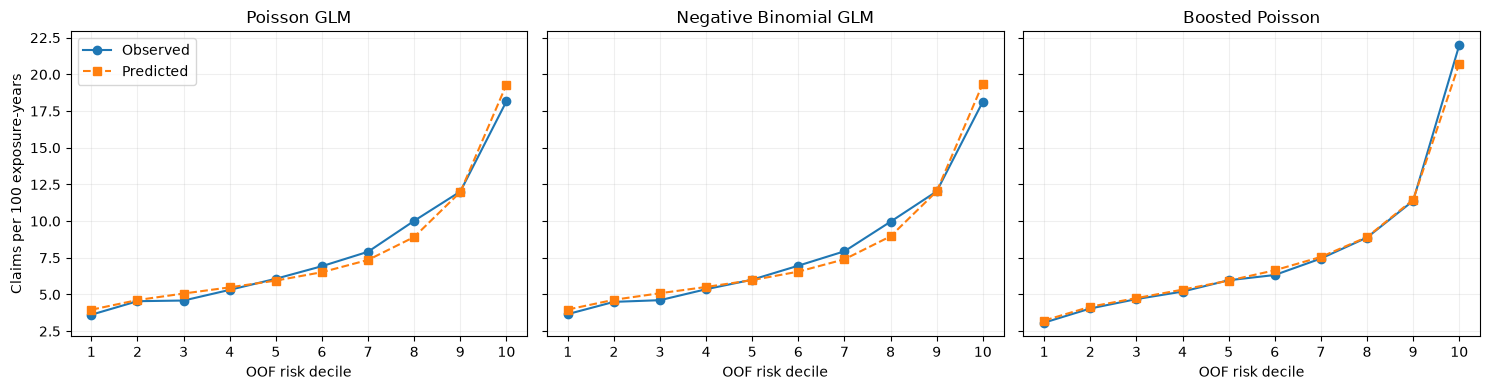

,model,claims,observed_mean,predicted_mean,observed_median,largest_observed_claim,O/P
risk_group,,,,,,,
1,Gamma GLM,4216,1829.99,1393.11,1172.0,369131.88,1.31
2,Gamma GLM,4216,2113.35,1774.81,1172.0,281897.49,1.19
3,Gamma GLM,4215,1791.35,2073.10,1172.0,183073.66,0.86
4,Gamma GLM,4216,2092.00,2440.52,1172.0,1301172.60,0.86
5,Gamma GLM,4216,3600.47,3456.83,1172.0,4075400.56,1.04


,model,claims,observed_mean,predicted_mean,observed_median,largest_observed_claim,O/P
risk_group,,,,,,,
1,Boosted Gamma,4216,1892.27,1302.82,1172.0,369131.88,1.45
2,Boosted Gamma,4216,2314.91,1496.50,1172.0,1403057.40,1.55
3,Boosted Gamma,4217,1992.64,1634.46,1172.0,276643.00,1.22
4,Boosted Gamma,4214,1783.61,1820.80,1172.0,181204.00,0.98
5,Boosted Gamma,4216,3443.68,2739.05,1172.0,4075400.56,1.26


,model,claims,observed_mean,predicted_mean,observed_median,largest_observed_claim,O/P
risk_group,,,,,,,
1,Lognormal (normal),4217,1953.91,1511.73,1128.12,1301172.60,1.29
2,Lognormal (normal),4215,3312.76,1643.18,1128.12,4075400.56,2.02
3,Lognormal (normal),4215,2255.83,1742.11,1172.00,281897.49,1.29
4,Lognormal (normal),4216,1883.14,1862.26,1172.00,307096.42,1.01
5,Lognormal (normal),4216,2021.96,2128.32,1172.00,205432.05,0.95


,model,claims,observed_mean,predicted_mean,observed_median,largest_observed_claim,O/P
risk_group,,,,,,,
1,Lognormal (smearing),4216,3221.59,1940.54,1128.12,4075400.56,1.66
2,Lognormal (smearing),4216,2248.29,2133.69,1172.00,369131.88,1.05
3,Lognormal (smearing),4215,2003.31,2278.43,1172.00,255013.03,0.88
4,Lognormal (smearing),4216,1889.98,2442.00,1172.00,307096.42,0.77
5,Lognormal (smearing),4216,2064.04,2801.92,1172.00,205432.05,0.74


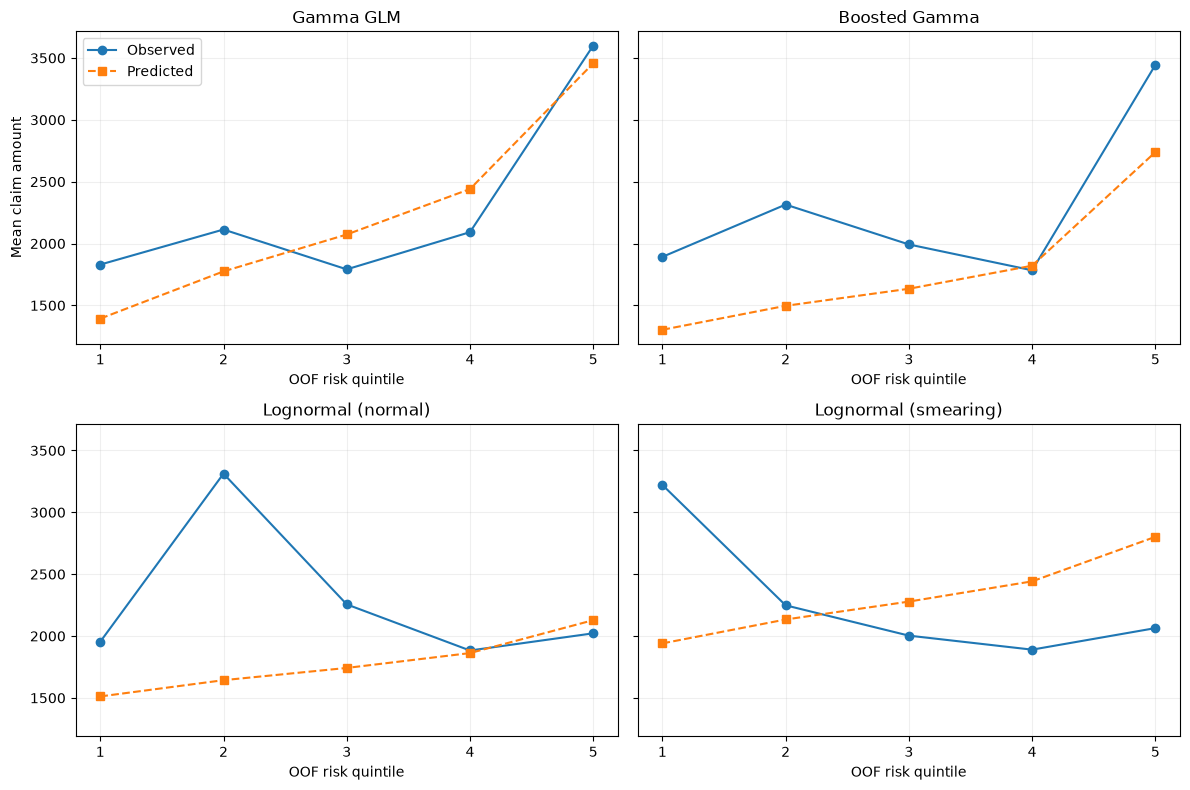

In [8]:
frequency_calibration_parts = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name in zip(axes, frequency_candidates):
    rows = frequency_oof.copy()
    rows["risk_group"] = pd.qcut(rows[name] / rows.Exposure, 10, labels=False, duplicates="drop") + 1
    table = rows.groupby("risk_group", observed=True).agg(
        policies=("IDpol", "size"), exposure=("Exposure", "sum"),
        observed_claims=("ClaimNb", "sum"), predicted_claims=(name, "sum"))
    table["observed_annual_frequency"] = table.observed_claims / table.exposure
    table["predicted_annual_frequency"] = table.predicted_claims / table.exposure
    table["O/P"] = table.observed_claims / table.predicted_claims
    table.insert(0, "model", name)
    frequency_calibration_parts.append(table.reset_index())
    display(table.drop(columns=["observed_claims", "predicted_claims"]).round(4))
    ax.plot(table.index, 100 * table.observed_annual_frequency, "o-", label="Observed")
    ax.plot(table.index, 100 * table.predicted_annual_frequency, "s--", label="Predicted")
    ax.set(title=name, xlabel="OOF risk decile", xticks=table.index)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Claims per 100 exposure-years")
axes[0].legend()
save_plot(fig, "frequency_oof_calibration_deciles")
frequency_calibration = pd.concat(frequency_calibration_parts, ignore_index=True)
frequency_calibration.to_csv(table_dir / "frequency_calibration.csv", index=False)

severity_calibration_parts = []
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()
for ax, name in zip(axes, severity_candidates):
    rows = severity_oof.copy()
    rows["risk_group"] = pd.qcut(rows[name], 5, labels=False, duplicates="drop") + 1
    table = rows.groupby("risk_group", observed=True).agg(
        claims=("IDpol", "size"), observed_mean=("ClaimAmount", "mean"),
        predicted_mean=(name, "mean"), observed_median=("ClaimAmount", "median"),
        largest_observed_claim=("ClaimAmount", "max"))
    table["O/P"] = table.observed_mean / table.predicted_mean
    table.insert(0, "model", name)
    severity_calibration_parts.append(table.reset_index())
    display(table.round(2))
    ax.plot(table.index, table.observed_mean, "o-", label="Observed")
    ax.plot(table.index, table.predicted_mean, "s--", label="Predicted")
    ax.set(title=name, xlabel="OOF risk quintile", xticks=table.index)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Mean claim amount")
axes[0].legend()
save_plot(fig, "severity_oof_calibration_quintiles")
severity_calibration = pd.concat(severity_calibration_parts, ignore_index=True)
severity_calibration.to_csv(table_dir / "severity_calibration.csv", index=False)

Boosted frequency has decile O/P ratios of approximately 0.95–1.06, versus 0.91–1.12 for the Poisson GLM. Its highest-risk decile still underpredicts by about 6% on an O/P basis. Neither original severity candidate is consistently calibrated across quintiles: observed means are not monotone through the middle groups, and the maxima show how a few claims affect those means. Gamma GLM's highest predicted-risk quintile has O/P about 1.04, compared with 1.26 for Boosted Gamma's highest quintile. The groups are model-specific, so these are calibration checks rather than comparisons of identical claim subsets.

Lognormal calibration is less persuasive than its pooled smearing O/P suggests. The normal-theory version puts the largest claim in its second quintile, whose O/P is 2.02; with smearing it falls in the lowest quintile, whose O/P is 1.66. The smeared highest quintile has O/P 0.74. Observed means do not rise with predicted severity across these groups. The corrections preserve ranking within a fold, but fold-specific scale factors can change pooled quintile membership. Smearing improves the aggregate level without establishing a useful conditional mean ranking; a single catastrophic observation still strongly influences these comparisons.

## 9. Fold stability and severity tail sensitivity

The same validation folds are compared for every candidate. For severity, the largest **observed** 1, 5 or 20 claims are then excluded separately within each validation fold, using the same retained rows for both models and fixed predictions. Ties in claim amount are broken by the existing development claim-row number. The zero-exclusion rows give the original results. This is a **sensitivity diagnostic only**: neither the fitting data, the severity target nor the saved OOF predictions are altered. Removing realized losses changes the evaluation sample and cannot establish that a model is better for the original expected-loss target.

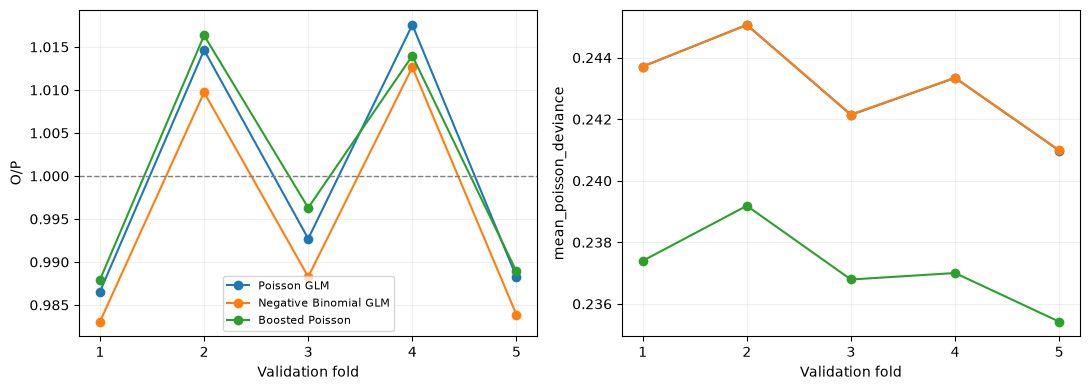

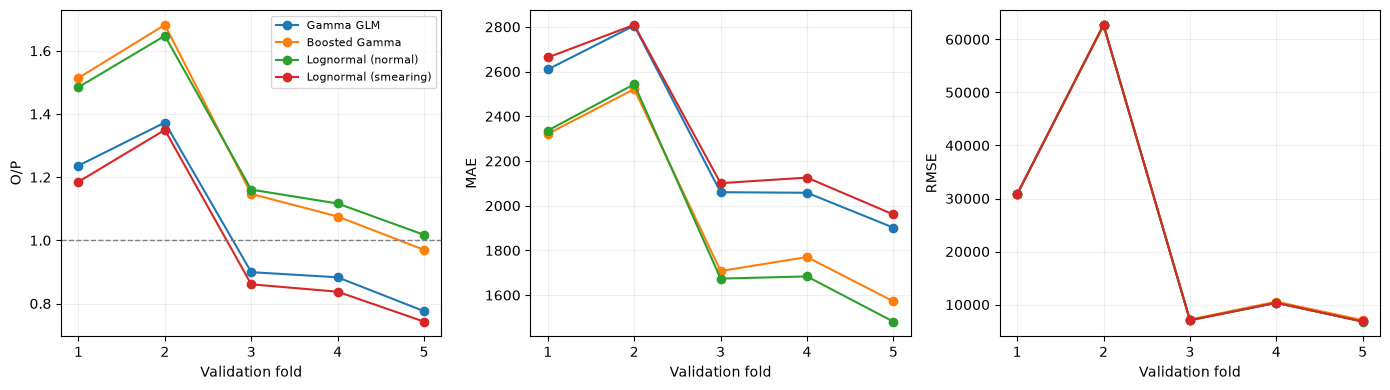

,model,fold,removed_per_fold,removed_loss_share,O/P,MAE,RMSE
0,Gamma GLM,1,0,0.000,1.236,2609.706,30782.387
1,Boosted Gamma,1,0,0.000,1.514,2321.258,30806.446
2,Lognormal (normal),1,0,0.000,1.485,2335.981,30808.049
3,Lognormal (smearing),1,0,0.000,1.185,2663.083,30799.716
4,Gamma GLM,2,0,0.000,1.373,2805.734,62703.889
5,Boosted Gamma,2,0,0.000,1.682,2521.595,62635.324
6,Lognormal (normal),2,0,0.000,1.647,2543.392,62733.739
7,Lognormal (smearing),2,0,0.000,1.350,2809.123,62728.289
8,Gamma GLM,3,0,0.000,0.899,2060.359,7104.744
9,Boosted Gamma,3,0,0.000,1.147,1707.814,7177.552


,model,removed_per_fold,retained_claims,removed_loss_share,observed_mean,predicted_mean,O/P,MAE,RMSE
0,Gamma GLM,0,21079,0.000,2285.457,2227.680,1.026,2288.745,32039.440
1,Boosted Gamma,0,21079,0.000,2285.457,1798.717,1.271,1980.503,32042.779
2,Lognormal (normal),0,21079,0.000,2285.457,1777.514,1.286,1945.565,32049.886
3,Lognormal (smearing),0,21079,0.000,2285.457,2319.316,0.985,2333.465,32048.135
4,Gamma GLM,1,21074,0.130,1988.822,2227.602,0.893,1992.717,11696.000
5,Boosted Gamma,1,21074,0.130,1988.822,1798.463,1.106,1684.477,11762.481
6,Lognormal (normal),1,21074,0.130,1988.822,1777.531,1.119,1649.254,11676.443
7,Lognormal (smearing),1,21074,0.130,1988.822,2319.338,0.857,2037.370,11681.964
8,Gamma GLM,5,21054,0.232,1757.804,2227.375,0.789,1764.047,4689.604
9,Boosted Gamma,5,21054,0.232,1757.804,1798.567,0.977,1454.774,4827.762


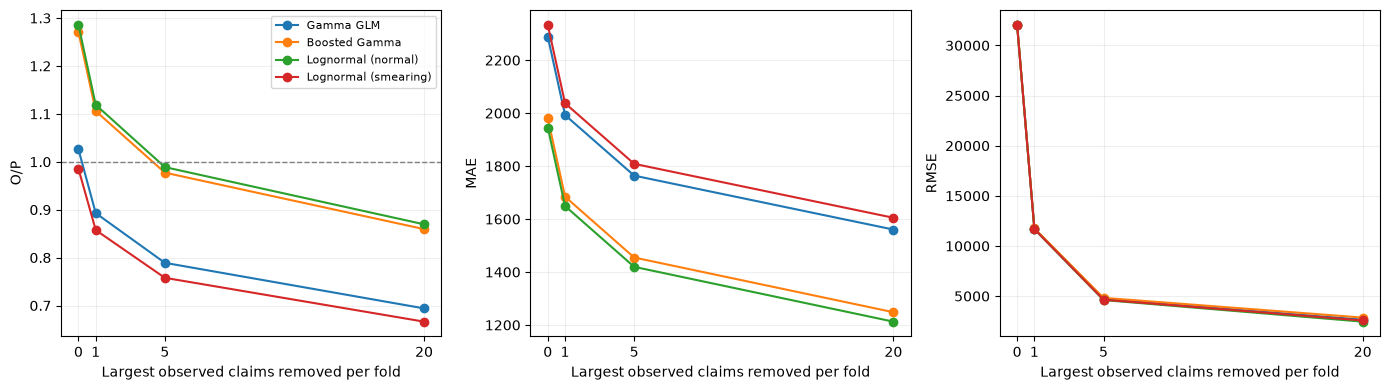

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in frequency_candidates:
    rows = frequency_fold_metrics.query("model == @name")
    for ax, metric in zip(axes, ["O/P", "mean_poisson_deviance"]):
        ax.plot(rows.fold, rows[metric], "o-", label=name)
        ax.set(xlabel="Validation fold", ylabel=metric, xticks=range(1, 6))
        ax.grid(alpha=0.2)
axes[0].axhline(1, color="gray", ls="--", lw=1)
axes[0].legend(fontsize=8)
save_plot(fig, "frequency_fold_stability")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name in severity_candidates:
    rows = severity_fold_metrics.query("model == @name")
    for ax, metric in zip(axes, ["O/P", "MAE", "RMSE"]):
        ax.plot(rows.fold, rows[metric], "o-", label=name)
        ax.set(xlabel="Validation fold", ylabel=metric, xticks=range(1, 6))
        ax.grid(alpha=0.2)
axes[0].axhline(1, color="gray", ls="--", lw=1)
axes[0].legend(fontsize=8)
save_plot(fig, "severity_fold_stability")

tail_rows, tail_pooled_rows = [], []
for removed in [0, 1, 5, 20]:
    retained_parts = []
    for fold_id, rows in severity_oof.groupby("cv_fold"):
        ordered = rows.sort_values(["ClaimAmount", "development_claim_row"], ascending=[False, True])
        retained = ordered.iloc[removed:]
        retained_parts.append(retained)
        for name in severity_candidates:
            tail_rows.append({"model": name, "fold": fold_id, "removed_per_fold": removed,
                              "retained_claims": len(retained),
                              "removed_loss_share": 1 - retained.ClaimAmount.sum() / rows.ClaimAmount.sum(),
                              **severity_metrics(retained, name)})
    pooled = pd.concat(retained_parts)
    for name in severity_candidates:
        tail_pooled_rows.append({"model": name, "removed_per_fold": removed,
                                "retained_claims": len(pooled),
                                "removed_loss_share": 1 - pooled.ClaimAmount.sum() / severity_oof.ClaimAmount.sum(),
                                **severity_metrics(pooled, name)})
tail_by_fold = pd.DataFrame(tail_rows)
tail_pooled = pd.DataFrame(tail_pooled_rows)
with pd.option_context("display.max_rows", 100):
    display(tail_by_fold[["model", "fold", "removed_per_fold", "removed_loss_share", "O/P", "MAE", "RMSE"]].round(3))
display(tail_pooled.round(3))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name in severity_candidates:
    rows = tail_pooled.query("model == @name")
    for ax, metric in zip(axes, ["O/P", "MAE", "RMSE"]):
        ax.plot(rows.removed_per_fold, rows[metric], "o-", label=name)
        ax.set(xlabel="Largest observed claims removed per fold", ylabel=metric, xticks=[0, 1, 5, 20])
        ax.grid(alpha=0.2)
axes[0].axhline(1, color="gray", ls="--", lw=1)
axes[0].legend(fontsize=8)
save_plot(fig, "severity_tail_sensitivity")
tail_by_fold.to_csv(table_dir / "severity_tail_sensitivity_by_fold.csv", index=False)
tail_pooled.to_csv(table_dir / "severity_tail_sensitivity_pooled.csv", index=False)

The severity comparison is highly sensitive to a handful of realized losses. Removing one claim per fold—five claims overall—removes 13.0% of observed loss and reduces pooled RMSE from about 32,040 to 11,696 for Gamma GLM and 11,762 for Boosted Gamma. Removing 20 per fold removes 32.7% of loss and reduces RMSE to 2,654 and 2,857, respectively.

Across exclusions of 0, 1, 5 and 20 per fold, Gamma GLM's pooled O/P moves from 1.026 to 0.893, 0.789 and 0.694; Boosted Gamma's moves from 1.271 to 1.106, 0.977 and 0.860. Compared with Gamma GLM, boosting remains better on MAE, and its aggregate calibration looks close to one after the largest five claims per fold are removed. That apparent improvement applies to a different realized loss mix. The uncapped expected-loss target includes these claims, and the diagnostic does not justify removing them. Conversely, Gamma GLM's favorable full-loss aggregate calibration is visibly tail-dependent and is not evidence that it predicts individual catastrophes well.

The normal-theory lognormal advantage is concentrated in the body of the distribution. Its pooled O/P moves from 1.286 to 1.119, 0.989 and 0.870 as 0, 1, 5 and 20 claims per fold are excluded. After removing 20 per fold, its MAE/RMSE are 1,213/2,453, compared with 1,560/2,654 for Gamma GLM and 1,248/2,857 for Boosted Gamma. This does not remedy its full-loss underprediction. Smearing's O/P instead moves from 0.985 to 0.857, 0.758 and 0.666: its full-loss calibration relies on the realized tail, and the higher scale overpredicts the diagnostically reduced samples. No observations are excluded from fitting or from the primary evaluation.

## 10. Predictor-response stability and retained fold models

The original fits were not persisted. The following cell reproduces exactly the five existing candidates within their original fitting folds, checks predictions against the saved OOF values, and stores the fitted objects. Subsequent runs reuse those artifacts. No full-development model is fitted. Statsmodels objects are saved in a compact prediction-ready form with observation arrays removed; their parameters and formula metadata are retained. These files should be loaded only from this trusted project and with the recorded package versions.

GLM curves hold a common reference profile fixed. Boosted curves use partial dependence, averaging predictions over the same fixed sample of 500 development covariate profiles across all five fits (exposure-weighted for annual frequency, equally weighted for severity). These two curve types have different averaging conventions and their levels should not be directly compared. They show fitted responses, not causal effects. Grids are restricted to the intersection of the five fitting ranges for each predictor; the support table makes those limits explicit. This avoids univariate out-of-range GLM extrapolation but does not guarantee dense data or support for every joint predictor combination.

The five lognormal regressions and their two fitting-fold correction factors are saved in Section 5.1. Their response curves use the same reference profile as the Gamma GLM, multiplied by the corresponding original-dollar correction. Existing response values for the initial five candidates are reused from the saved diagnostic table.

In [10]:
import joblib
import sklearn
import statsmodels

model_dir = Path("../models/05_cv")
model_dir.mkdir(parents=True, exist_ok=True)
versions = {"numpy": np.__version__, "pandas": pd.__version__,
            "sklearn": sklearn.__version__, "statsmodels": statsmodels.__version__}
model_keys = {"Poisson GLM": "poisson_glm", "Negative Binomial GLM": "negative_binomial_glm",
              "Boosted Poisson": "boosted_poisson", "Gamma GLM": "gamma_glm", "Boosted Gamma": "boosted_gamma"}
verification_rows = []

def model_prediction(model, name, rows, task):
    if name.startswith("Boosted"):
        prediction = model.predict(tree_features(rows))
        return prediction * rows.Exposure.to_numpy() if task == "frequency" else prediction
    if task == "frequency":
        return np.asarray(model.predict(rows, exposure=rows.Exposure.to_numpy()))
    return np.asarray(model.predict(rows))

for task, data, saved, names in [
    ("frequency", development_policies, frequency_oof, frequency_candidates),
    ("severity", development_claims, severity_oof, severity_candidates[:2]),
]:
    for fold_id in range(1, 6):
        fitting = data.loc[data.cv_fold.ne(fold_id)]
        validation = data.loc[data.cv_fold.eq(fold_id)]
        for name in names:
            artifact_path = model_dir / f"{model_keys[name]}_fold_{fold_id}.joblib"
            if artifact_path.exists():
                artifact = joblib.load(artifact_path)
                assert artifact["oof_hashes"] == oof_hashes
                assert artifact["versions"] == versions
                fitted = artifact["model"]
            else:
                print(f"Recovering {name}, fold {fold_id}", flush=True)
                alpha = None
                if name.startswith("Boosted"):
                    fitted = HistGradientBoostingRegressor(
                        loss="poisson" if task == "frequency" else "gamma",
                        max_iter=150, learning_rate=0.05, max_leaf_nodes=15,
                        min_samples_leaf=100 if task == "frequency" else 50,
                        l2_regularization=10, early_stopping=False,
                        categorical_features="from_dtype", random_state=2027)
                    if task == "frequency":
                        fitted.fit(tree_features(fitting), fitting.ClaimNb / fitting.Exposure,
                                   sample_weight=fitting.Exposure.to_numpy())
                    else:
                        fitted.fit(tree_features(fitting), fitting.ClaimAmount)
                elif task == "frequency":
                    poisson = sm.GLM.from_formula("ClaimNb ~ " + glm_predictors, data=fitting,
                        family=sm.families.Poisson(), exposure=fitting.Exposure.to_numpy()).fit(maxiter=100)
                    assert poisson.converged
                    if name == "Poisson GLM":
                        fitted = poisson
                    else:
                        mu = np.asarray(poisson.fittedvalues)
                        y = fitting.ClaimNb.to_numpy()
                        alpha = max(0.001, np.sum((y - mu) ** 2 - y) / np.sum(mu ** 2))
                        fitted = sm.GLM.from_formula("ClaimNb ~ " + glm_predictors, data=fitting,
                            family=sm.families.NegativeBinomial(alpha=alpha),
                            exposure=fitting.Exposure.to_numpy()).fit(maxiter=100)
                        assert fitted.converged
                else:
                    model = sm.GLM.from_formula("ClaimAmount ~ " + glm_predictors, data=fitting,
                        family=sm.families.Gamma(link=sm.families.links.Log()))
                    start = np.zeros(model.exog.shape[1])
                    start[model.exog_names.index("Intercept")] = np.log(fitting.ClaimAmount.mean())
                    fitted = model.fit(start_params=start, method="bfgs", maxiter=1000)
                    assert fitted.mle_retvals["converged"]
                prediction = model_prediction(fitted, name, validation, task)
                np.testing.assert_allclose(prediction, saved.loc[validation.index, name], rtol=1e-8, atol=1e-7)
                if not name.startswith("Boosted"):
                    fitted.remove_data()
                artifact = {"model": fitted, "candidate": name, "fold": fold_id,
                            "task": task, "formula": glm_predictors, "nb_alpha": alpha,
                            "category_levels": category_levels, "versions": versions,
                            "oof_hashes": oof_hashes,
                            "support": {x: [float(fitting[x].min()), float(fitting[x].max())]
                                        for x in ["DrivAge", "BonusMalus", "Density"]}}
                joblib.dump(artifact, artifact_path, compress=3)
                artifact = joblib.load(artifact_path)
                fitted = artifact["model"]
            prediction = model_prediction(fitted, name, validation, task)
            np.testing.assert_allclose(prediction, saved.loc[validation.index, name], rtol=1e-8, atol=1e-7)
            verification_rows.append({"model": name, "fold": fold_id,
                "max_absolute_prediction_difference": np.max(np.abs(prediction - saved.loc[validation.index, name]))})
display(pd.DataFrame(verification_rows))
print("All 25 original candidate fold models reproduce the existing OOF predictions.")
model_keys.update({name: "lognormal" for name in lognormal_names})

,model,fold,max_absolute_prediction_difference
0,Poisson GLM,1,1.110223e-16
1,Negative Binomial GLM,1,9.996344e-17
2,Boosted Poisson,1,9.990923e-17
3,Poisson GLM,2,9.996344e-17
4,Negative Binomial GLM,2,9.996344e-17
5,Boosted Poisson,2,9.996344e-17
6,Poisson GLM,3,1.110223e-16
7,Negative Binomial GLM,3,9.996344e-17
8,Boosted Poisson,3,9.996344e-17
9,Poisson GLM,4,9.996344e-17


All 25 saved fold models reproduce the existing OOF predictions.


,DrivAge,BonusMalus,VehAge,VehPower,VehGas,Density,Region
0,45,70,6,6,Diesel,393.0,Centre


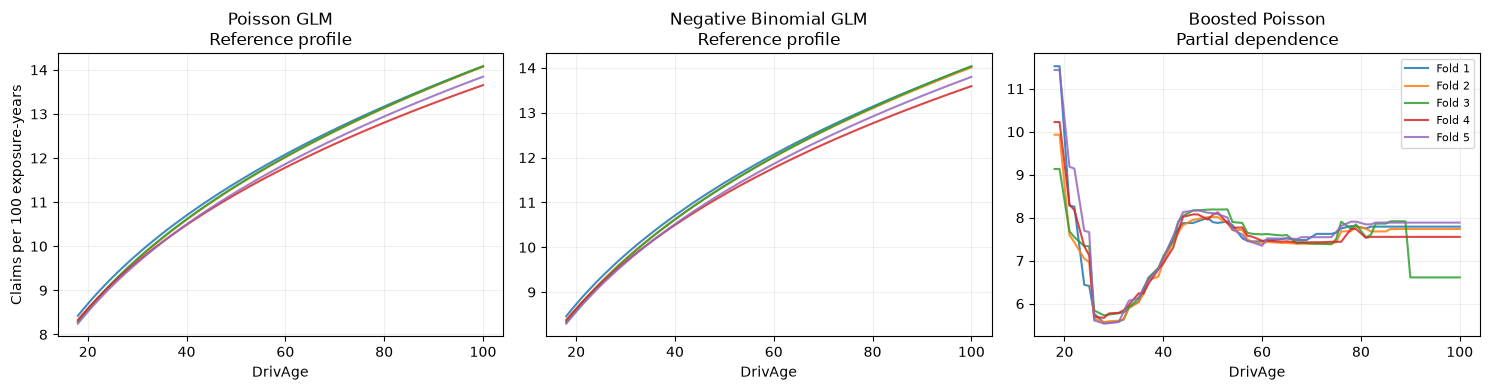

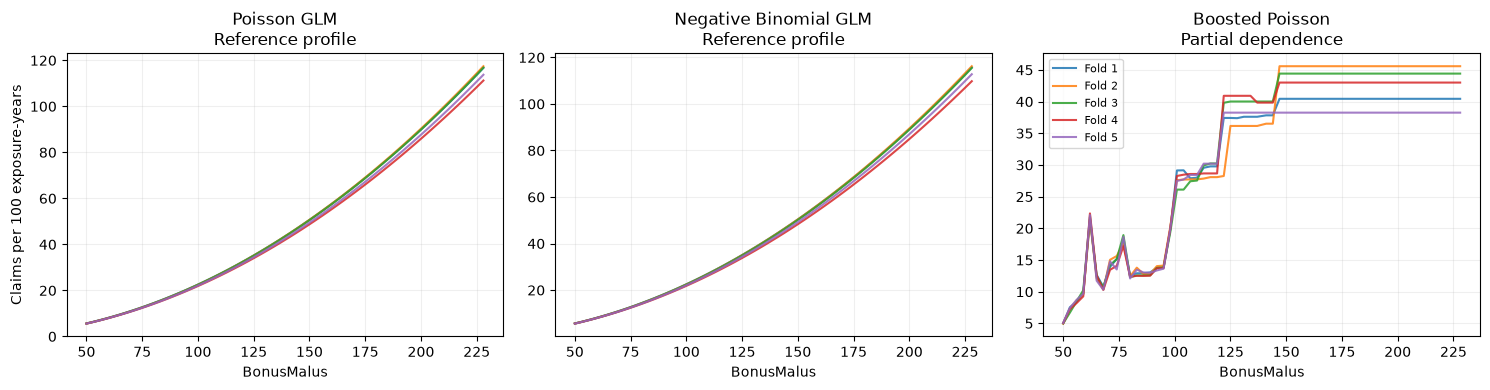

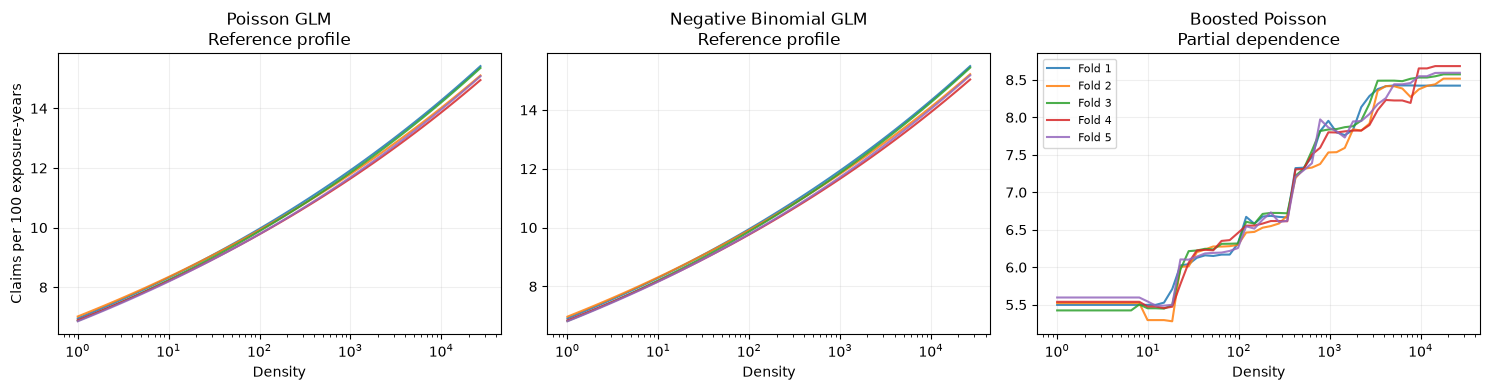

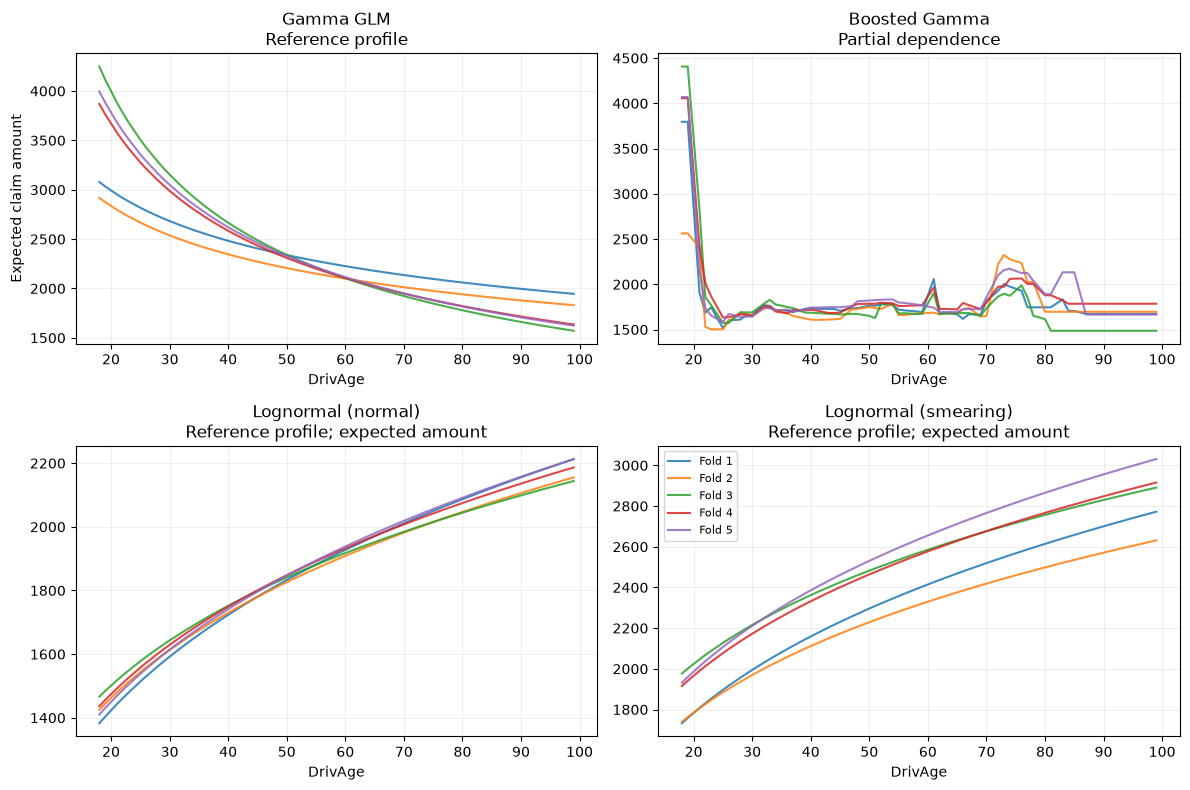

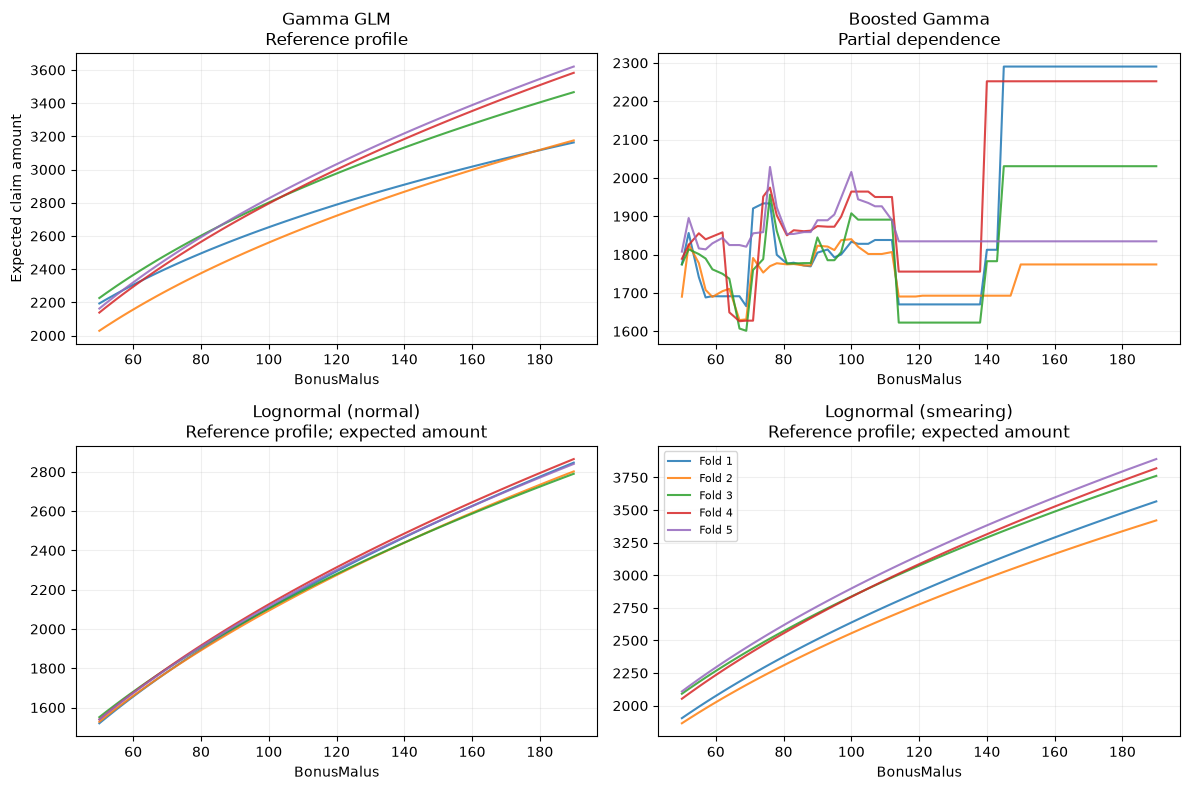

,task,predictor,fold,fit_min,fit_max,grid_min,grid_max
0,frequency,DrivAge,1,18,100,18,100
1,frequency,DrivAge,2,18,100,18,100
2,frequency,DrivAge,3,18,100,18,100
3,frequency,DrivAge,4,18,100,18,100
4,frequency,DrivAge,5,18,100,18,100
5,frequency,BonusMalus,1,50,230,50,228
6,frequency,BonusMalus,2,50,230,50,228
7,frequency,BonusMalus,3,50,228,50,228
8,frequency,BonusMalus,4,50,230,50,228
9,frequency,BonusMalus,5,50,230,50,228


median_fold_CV  maximum_fold_CV
task      model                 predictor                                  
frequency Boosted Poisson       BonusMalus           0.055            0.136
                                Density              0.012            0.030
                                DrivAge              0.015            0.098
          Negative Binomial GLM BonusMalus           0.017            0.024
                                Density              0.009            0.012
                                DrivAge              0.010            0.014
          Poisson GLM           BonusMalus           0.017            0.023
                                Density              0.009            0.013
                                DrivAge              0.010            0.014
severity  Boosted Gamma         BonusMalus           0.048            0.128
                                DrivAge              0.037            0.189
          Gamma GLM             BonusMalus           0.048            0.065
                                DrivAge              0.059            0.162
          Lognormal (normal)    BonusMalus           0.007            0.011
                                DrivAge              0.010            0.022
          Lognormal (smearing)  BonusMalus           0.053            0.056
                                DrivAge              0.054            0.062

The original OOF files are byte-for-byte unchanged.


In [11]:
reference_profile = {
    "DrivAge": 45, "BonusMalus": 70, "VehAge": 6, "VehPower": 6,
    "VehGas": "Diesel", "Density": float(development_policies.Density.median()),
    "Region": development_policies.Region.mode().iloc[0],
}
display(pd.DataFrame([reference_profile]))
existing_curves = pd.read_csv(table_dir / "fold_response_curves.csv")
response_rows, support_rows = [], []
for task, data, names, predictors in [
    ("frequency", development_policies, frequency_candidates, ["DrivAge", "BonusMalus", "Density"]),
    ("severity", development_claims, severity_candidates, ["DrivAge", "BonusMalus"]),
]:
    background = data.sample(n=500, random_state=2028).copy()
    weights = background.Exposure.to_numpy() if task == "frequency" else np.ones(len(background))
    for predictor in predictors:
        ranges = [data.loc[data.cv_fold.ne(f), predictor].agg(["min", "max"]) for f in range(1, 6)]
        lower, upper = max(r["min"] for r in ranges), min(r["max"] for r in ranges)
        grid = np.geomspace(lower, upper, 50) if predictor == "Density" else np.unique(np.rint(np.linspace(lower, upper, 60)))
        for f, bounds in enumerate(ranges, start=1):
            support_rows.append({"task": task, "predictor": predictor, "fold": f,
                                 "fit_min": bounds["min"], "fit_max": bounds["max"],
                                 "grid_min": lower, "grid_max": upper})
        fig, axes = plt.subplots(2, 2, figsize=(12, 8)) if task == "severity" else plt.subplots(1, len(names), figsize=(5 * len(names), 4))
        axes = np.asarray(axes).ravel()
        for ax, name in zip(axes, names):
            for fold_id in range(1, 6):
                if name not in lognormal_names:
                    saved = existing_curves.loc[
                        existing_curves.task.eq(task) & existing_curves.model.eq(name)
                        & existing_curves.predictor.eq(predictor) & existing_curves.fold.eq(fold_id)
                    ].sort_values("value")
                    np.testing.assert_allclose(saved.value, grid)
                    values = saved.response.to_numpy()
                    curve_kind = saved.curve_kind.iloc[0]
                else:
                    artifact = joblib.load(model_dir / f"lognormal_fold_{fold_id}.joblib")
                    profiles = pd.DataFrame([reference_profile] * len(grid))
                    profiles[predictor] = grid
                    factor_key = "normal_factor" if name == lognormal_names[0] else "smearing_factor"
                    values = np.exp(artifact["model"].predict(profiles)) * artifact["correction"][factor_key]
                    curve_kind = "Reference profile; expected amount"
                assert np.isfinite(values).all() and np.asarray(values).min() > 0
                for point, value in zip(grid, values):
                    response_rows.append({"task": task, "model": name, "predictor": predictor,
                                          "fold": fold_id, "value": point, "response": value,
                                          "curve_kind": curve_kind})
                ax.plot(grid, np.asarray(values) * (100 if task == "frequency" else 1), label=f"Fold {fold_id}", alpha=0.85)
            ax.set(title=f"{name}\n{curve_kind}", xlabel=predictor)
            ax.grid(alpha=0.2)
            if predictor == "Density":
                ax.set_xscale("log")
        axes[0].set_ylabel("Claims per 100 exposure-years" if task == "frequency" else "Expected claim amount")
        axes[-1].legend(fontsize=8)
        save_plot(fig, f"{task}_{predictor.lower()}_fold_response")
response_curves = pd.DataFrame(response_rows)
support_table = pd.DataFrame(support_rows)
display(support_table)
spread = response_curves.groupby(["task", "model", "predictor", "value"]).response.agg(["min", "max", "mean", "std"])
spread["fold_CV"] = spread["std"] / spread["mean"]
response_stability = spread.groupby(["task", "model", "predictor"]).agg(
    median_fold_CV=("fold_CV", "median"), maximum_fold_CV=("fold_CV", "max"))
display(response_stability.round(3))
response_curves.to_csv(table_dir / "fold_response_curves.csv", index=False)
support_table.to_csv(table_dir / "fold_predictor_support.csv", index=False)
response_stability.to_csv(table_dir / "response_stability.csv")
assert {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in [frequency_path, severity_path]} == oof_hashes
print("The original OOF files are byte-for-byte unchanged.")

The frequency GLM curves are very consistent across folds but impose a simple monotone age response. Boosted frequency repeatedly finds a different nonlinear age shape; its age and density curves are broadly similar across folds, while the sparse age and BonusMalus extremes vary more. The largest pointwise fold coefficient of variation in its plotted curves is about 10% for age, 14% for BonusMalus and 3% for density. This greater flexibility has a stability cost even though OOF predictive metrics improve.

Both original severity candidates show material young-driver variation across fitting folds. For Gamma GLM, the largest pointwise fold coefficient of variation is about 16% along the age curve and 6% along BonusMalus; the corresponding boosted partial-dependence curves reach about 19% and 13%. These summaries describe within-model variation under different averaging conventions, not a formal comparison of uncertainties. Gamma's smooth, monotone shapes are partly imposed by its log transforms. Neither candidate establishes a stable causal age or BonusMalus relationship. All displayed GLM grid points lie within every fold's fitting range, including the severity BonusMalus limit of 190.

The lognormal reference curves are considerably steadier: the maximum pointwise fold coefficient of variation is about 2.2% for driver age and 1.1% for BonusMalus under normal-theory correction. Smearing raises those values to about 6.2% and 5.6%. Its predicted fold means also vary more (standard deviation 121 versus 16 under normal theory). This largely reflects the correction rather than a different fitted relationship. Stable curves alone are insufficient when the resulting original-dollar predictions are undercalibrated or poorly ordered across risk groups.

## 11. Conventional model comparison and selection at this stage

**Frequency remains Boosted Poisson.** Its roughly 2.4% deviance improvement, consistent fold results and closer risk-decile calibration remain the basis for selection. This addition does not change its predictors or settings.

**Retain Gamma GLM as the provisional conventional severity choice.** Normal-theory lognormal performs well for modest losses and on MAE, but predicts a full-loss mean about 22% below the observed mean; its O/P is 1.286. Smearing gives slightly closer pooled calibration than Gamma (0.985 versus 1.026), but worse full-loss MAE (2,333 versus 2,289), essentially indistinguishable catastrophe-dominated RMSE, and weak quintile calibration. Its aggregate improvement does not identify which claims will generate the tail. This combination does not provide sufficient evidence to replace Gamma, whose own aggregate calibration remains strongly dependent on catastrophic losses. The result is a development-stage choice among these candidates, not validation of the Gamma conditional distribution or tail.

**Retransformation is a substantive source of uncertainty.** The fitting-fold normal factors are 1.855–1.873; empirical smearing factors are 2.264–2.557, raising otherwise identical fold predictions by 22–37% (about 30% in the pooled mean). The largest fitting exponential residual contributes 4.2–11.7% of the smearing sum. The heavier theoretical lognormal tail therefore does not automatically recover the observed arithmetic mean, and empirical retransformation remains exposed to a few large claims. The diagnostic exclusions show body-loss advantages for normal-theory lognormal; they do not demonstrate better prediction of catastrophic losses.

At the close of this comparison, Gamma was retained as the provisional conventional severity benchmark. Notebook 06 subsequently tested an explicit body/tail approach on development data and retained Gamma as the comparatively stable conditional-mean benchmark. Notebook 07 then refit the selected Boosted Poisson frequency and Gamma severity specifications on all development data and performed the reserved-test evaluation. The test results did not reopen model selection.

In [4]:
selection_path = Path("../models/05_selected_specifications.json")
current_specifications = json.loads(selection_path.read_text(encoding="utf-8"))
assert current_specifications["frequency"]["candidate"] == "Boosted Poisson"
assert current_specifications["severity"]["candidate"] == "Gamma GLM"
assert current_specifications["severity"]["formula"] == "ClaimAmount ~ " + glm_predictors
assert current_specifications["oof_sha256"] == oof_hashes
current_specifications.update({
    "status": "provisional_selection_before_notebook_06",
    "conventional_severity_comparison_status": "complete_including_lognormal_retransformation_check",
    "selection_basis": "Original-dollar development OOF performance, calibration, stability and tail sensitivity; Gamma retained after lognormal comparison",
    "additional_oof_sha256": {
        "05_lognormal_severity_oof.csv": hashlib.sha256((processed_dir / "05_lognormal_severity_oof.csv").read_bytes()).hexdigest()
    },
    "lognormal_benchmark": {
        "formula": lognormal_formula,
        "fit": "Ordinary least squares on log(ClaimAmount), same predictors as Gamma",
        "normal_retransformation": "exp(predicted log amount + sigma_squared / 2); sigma_squared = mean squared fitting residual",
        "smearing_check": "exp(predicted log amount) * mean(exp(fitting residual))",
        "correction_estimated_from": "Fitting portion of each policy-level CV fold only",
        "selected": False,
        "fold_models": "models/05_cv/lognormal_fold_1.joblib through lognormal_fold_5.joblib",
    },
    "next_step": "Notebook 06: development-only extreme-severity work; Notebook 07: full-development refit and final test evaluation",
    "full_development_refit_performed": False,
    "final_test_evaluation_performed": False,
})
selection_path.write_text(json.dumps(current_specifications, indent=2), encoding="utf-8")
assert {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in [frequency_path, severity_path]} == oof_hashes
print("Current frequency selection: Boosted Poisson")
print("Current conventional severity selection: Gamma GLM")
print("Lognormal comparison and retransformation checks complete; existing OOF files unchanged.")
print(f"Updated specifications: {selection_path}")

Current frequency selection: Boosted Poisson
Current conventional severity selection: Gamma GLM
Lognormal comparison and retransformation checks complete; existing OOF files unchanged.
Updated specifications: ..\models\05_selected_specifications.json


## Summary and Model-Development Conclusions

This notebook compared candidate models using five policy-level folds entirely within the 80% development sample. Every reported validation prediction was made out of fold. The exercise supports development-stage model choice and exposes instability; it is not an estimate of final performance on the reserved 20% test sample.

For frequency, Poisson and Negative Binomial GLMs had effectively identical mean OOF Poisson deviance (about 0.24305). Boosted Poisson reduced it to 0.23716, an improvement of roughly 2.4% that held in every fold. Its aggregate O/P was 1.00069, and calibration across model-specific predicted-risk deciles was generally closer to one. The earlier Poisson overdispersion was real, but this Negative Binomial specification did not materially improve out-of-fold conditional-mean prediction. Boosting's gain is consistent with useful nonlinearities and interactions in the mean function. **Boosted Poisson is the selected development-stage frequency model.**

Severity selection is harder because expected loss depends on the arithmetic conditional mean, $E[Y\mid X]$, while a few catastrophic claims dominate observed loss. Against the observed mean of 2,285.46, the Gamma GLM predicted 2,227.68 (O/P 1.026); Boosted Gamma predicted 1,798.72 (O/P 1.271). Boosting lowered original-dollar MAE from 2,289 to 1,981, but underpredicted aggregate loss, and both models had catastrophe-dominated RMSE near 32,040. Lower MAE on the many modest claims is therefore insufficient to establish the better expected-severity model. Gamma's closer aggregate calibration is itself sensitive to which catastrophic claims fell in validation folds; it does not validate the Gamma conditional distribution or its tail.

The lognormal comparison sharpened the distinction between fitting log amounts and estimating expected dollars. Normal-theory retransformation predicted mean severity of 1,777.51 (O/P 1.286) and achieved the lowest MAE, about 1,946, but substantially underpredicted the full arithmetic mean. Empirical smearing of the **same log regression** raised the predicted mean to 2,319.32 (O/P 0.985), yet did not establish reliable risk ranking across predicted-severity quintiles. The fitting-fold normal factors were 1.855–1.873 versus smearing factors of 2.264–2.557; one extreme fitting residual contributed 4.2–11.7% of each fold's smearing sum. Relatively stable fitted log-scale relationships can therefore yield materially different expected-dollar predictions depending on a tail-sensitive retransformation. A heavier theoretical lognormal tail alone did not solve conditional-mean estimation.

Tail sensitivity explains much of this difficulty. The largest one, five, and 20 observed claims **per validation fold** accounted for about 13%, 23%, and 33% of total observed loss across the five folds. Gamma's pooled O/P moved from 1.026 on all claims to 0.893, 0.789, and 0.694 after their diagnostic exclusion; normal-theory lognormal moved from 1.286 to 1.119, 0.989, and 0.870. The lognormal version fits the ordinary body better under these reduced evaluations, while both aggregate severity and retransformation remain sensitive to the extreme tail. These exclusions are sensitivity diagnostics only: the large claims are real losses and remain in the modeling target. Taken together, the development results suggest that the available rating variables predict claim occurrence more reproducibly than they predict the size of rare catastrophic claims.

**Gamma GLM remains the provisional conventional expected-severity baseline at this stage, not a final single-distribution severity choice.** Its overall mean calibration among the tested candidates is useful, but no candidate demonstrated robust tail estimation. Notebook 06 subsequently investigated an explicit severity body/tail approach using development data and retained Gamma as the more stable benchmark. Notebook 07 then evaluated the frozen choices on the reserved final 20% test sample; those results did not trigger further model changes. The test sample was not used for any analysis in this notebook.